In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from torchvision.transforms import v2
from torchvision.transforms.v2 import functional as v2F

In [ ]:
df_unfiltred = pd.read_parquet(
    "/projects/smala3/Ivan/reimaged_full/cellpose_bboxes.parquet"
)
(
    df_unfiltred["c_y"].min(),
    df_unfiltred["c_x"].min(),
    df_unfiltred["c_y"].max(),
    df_unfiltred["c_x"].max(),
)

(np.float64(2.7574750830564785),
 np.float64(1.5686274509803921),
 np.float64(1497.5979381443299),
 np.float64(1496.0813953488373))

In [ ]:
df = pd.read_parquet(
    "/projects/smala3/Ivan/reimaged_full/cellpose_bboxes_pooled_coords_at192.parquet"
)
df.head()
df.shape

,img_path,c_x,c_y,area,slide_id,label,mask_crop_path
0,/projects/smala3/Saranga/preprocessed_data/ful...,"[0.8821357695385437, 0.8180215780579748, 0.650...","[0.06471041166533298, 0.0878250357467828, 0.10...","[0.30103986831011365, 0.30886899265266793, 0.3...",ASY001V0,2,/projects/smala3/Ivan/reimaged_full/cellpose_f...
1,/projects/smala3/Saranga/preprocessed_data/ful...,"[0.254875068888041, 0.1909149506110832, 0.5874...","[0.06891161134427064, 0.07704545454545454, 0.0...","[0.3156943831051512, 0.31974946802103826, 0.33...",ASY001V0,2,/projects/smala3/Ivan/reimaged_full/cellpose_f...
2,/projects/smala3/Saranga/preprocessed_data/ful...,"[0.11103986859787965, 0.5279235843626865, 0.83...","[0.0682040714747897, 0.0716830034975871, 0.078...","[0.26888023447223675, 0.3022844983338017, 0.33...",ASY001V0,2,/projects/smala3/Ivan/reimaged_full/cellpose_f...
3,/projects/smala3/Saranga/preprocessed_data/ful...,"[0.3027621325361236, 0.7826364988842053, 0.497...","[0.07168938714499253, 0.08903430035540126, 0.0...","[0.2685991889830168, 0.3238447022925282, 0.247...",ASY001V0,2,/projects/smala3/Ivan/reimaged_full/cellpose_f...
4,/projects/smala3/Saranga/preprocessed_data/ful...,"[0.8936525965118558, 0.24490463975518656, 0.81...","[0.07960705467372134, 0.08170820395121732, 0.1...","[0.3414702694021761, 0.29738627695025494, 0.30...",ASY001V0,2,/projects/smala3/Ivan/reimaged_full/cellpose_f...


In [62]:
sample_id = 10
crop_size = 1500
tf = v2.Compose([v2.ToImage(), v2.CenterCrop([crop_size] * 2)])

img_path = df.iloc[sample_id]["img_path"]
n_cells_raw = df_unfiltred[df_unfiltred.img_path == img_path].shape[0]
n_cells_filtred = len(df.iloc[sample_id]["area"])

n_cells_raw, n_cells_filtred

(166, 121)

In [63]:
df_unfiltred[df_unfiltred.img_path == img_path]

,c_y,c_x,y1,x1,y2,x2,area,img_path,slide_id,h,w,pred_id
0,16.661730,259.504677,0,219,41,302,2566.0,/projects/smala3/Saranga/preprocessed_data/ful...,ASY001V3,41,83,0
1,27.157361,417.437138,0,371,63,464,4836.0,/projects/smala3/Saranga/preprocessed_data/ful...,ASY001V3,63,93,1
2,34.084619,795.971746,0,741,80,849,6937.0,/projects/smala3/Saranga/preprocessed_data/ful...,ASY001V3,80,108,2
3,17.152377,946.220517,0,905,43,989,2671.0,/projects/smala3/Saranga/preprocessed_data/ful...,ASY001V3,43,84,3
4,15.183571,1157.144234,0,1107,39,1199,2593.0,/projects/smala3/Saranga/preprocessed_data/ful...,ASY001V3,39,92,4
...,...,...,...,...,...,...,...,...,...,...,...,...
161,1483.411237,167.186497,1463,132,1500,203,2118.0,/projects/smala3/Saranga/preprocessed_data/ful...,ASY001V3,37,71,161
162,1484.436355,919.441308,1464,883,1500,960,2019.0,/projects/smala3/Saranga/preprocessed_data/ful...,ASY001V3,36,77,162
163,1484.208039,246.088339,1467,209,1500,285,2264.0,/projects/smala3/Saranga/preprocessed_data/ful...,ASY001V3,33,76,163
164,1487.427429,328.084256,1472,292,1500,365,1626.0,/projects/smala3/Saranga/preprocessed_data/ful...,ASY001V3,28,73,164


### DF unfiltred plot

torch.Size([3, 1500, 1500])
(1500, 1500, 3)


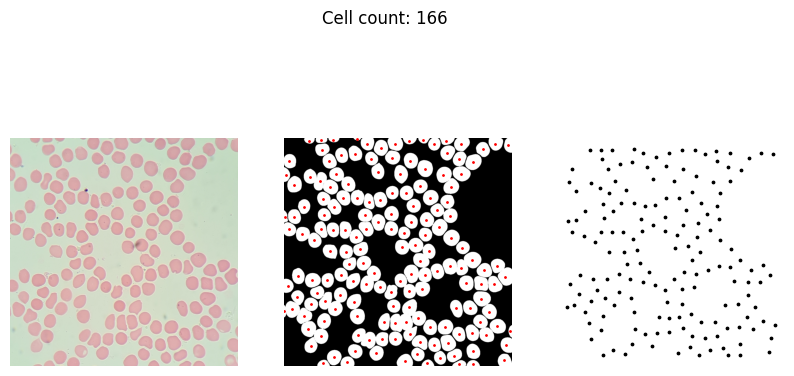

In [73]:
img = tf(Image.open(df["img_path"][sample_id]))
mask = Image.open(df["mask_crop_path"][sample_id])
print(img.shape)
print(np.array(mask).shape)

cxy = df_unfiltred[df_unfiltred.img_path == img_path][["c_x", "c_y"]].values
c_x = cxy[:, 0]
c_y = cxy[:, 1]

fig, ax = plt.subplots(1, 3, figsize=(10, 5))
fig.suptitle(f"Cell count: {cxy.shape[0]}")
ax[0].imshow(v2F.to_pil_image(img), origin="lower")
ax[1].imshow(mask, origin="lower")
ax[1].scatter(c_x, c_y, s=1.0, c="r")
ax[2].scatter(c_x, c_y, c="black", s=3.0)
ax[2].set_aspect("equal")
for a in ax:
    a.axis("off")
fig.show()

### DF filtred plot

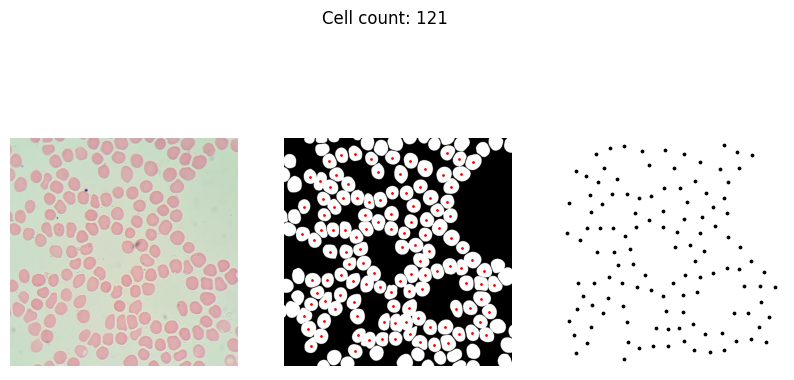

In [74]:
c_x, c_y = df[["c_x", "c_y"]].values[sample_id]

fig, ax = plt.subplots(1, 3, figsize=(10, 5))
fig.suptitle(f"Cell count: {c_x.shape[0]}")

ax[0].imshow(v2F.to_pil_image(img), origin="lower")
ax[1].imshow(mask, origin="lower")
ax[1].scatter(c_x * 1500, c_y * 1500, s=1.0, c="r")
ax[2].scatter(c_x, c_y, c="black", s=3.0)
ax[2].set_aspect("equal")
for a in ax:
    a.axis("off")
fig.show()